# k-Means: partitionierendes Clustering von Grund auf

**Notebook 06 der Reihe *Algorithmen des Maschinellen Lernens***

Autor: Mark Baumann · Sprache: Deutsch · Kernel: Python 3

---

## Zusammenfassung

Alle bisherigen Notebooks (01–05) behandelten **überwachtes** Lernen mit bekannten
Zielgrößen $y$. k-Means ist der erste Vertreter **unüberwachten** Lernens dieser Reihe:
Es gruppiert Beobachtungen ausschließlich anhand ihrer Merkmale $\mathbf{x}$, ohne
Labels. Dieses Notebook leitet das k-Means-Zielfunktional her, implementiert Lloyds
Algorithmus samt k-means++-Initialisierung mit `NumPy`, zeigt empirisch die
Konvergenz gegen lokale (nicht notwendig globale) Optima, vergleicht die
Ellenbogen-Methode mit dem Silhouettenkoeffizient zur Wahl von $k$, demonstriert die
Kernannahme sphärischer, ähnlich großer Cluster an einem Fall, in dem sie verletzt
ist, und validiert die Implementierung gegen `scikit-learn`.

## Lernziele

Nach Bearbeitung dieses Notebooks können Sie

1. das k-Means-Zielfunktional (Within-Cluster Sum of Squares) formal angeben,
2. Lloyds Algorithmus als alternierende Minimierung herleiten und seine
   Konvergenzeigenschaften (monotone Abnahme, nur lokales Optimum) begründen,
3. den Effekt der Initialisierung (zufällig vs. k-means++) auf die Lösungsqualität
   einschätzen,
4. die Ellenbogen-Methode und den Silhouettenkoeffizienten zur Wahl von $k$ anwenden
   und interpretieren,
5. die Modellannahme sphärischer, gleich großer Cluster benennen und einen Fall
   konstruieren, in dem sie versagt.

## Inhalt

1. [Theoretischer Rahmen](#1)
2. [Rechenumgebung](#2)
3. [Datengrundlage](#3)
4. [Implementierung](#4)
5. [Empirische Analyse](#5)
6. [Diskussion und Grenzen](#6)
7. [Übungsaufgaben](#7)
8. [Literatur](#8)

<a id="1"></a>
## 1 Theoretischer Rahmen

### 1.1 Zielfunktional

Gegeben $\mathbf{x}_1,\dots,\mathbf{x}_n\in\mathbb{R}^p$ ohne Labels, sucht k-Means
eine Partition in $k$ Cluster $C_1,\dots,C_k$ mit Zentren (Zentroiden)
$\boldsymbol\mu_1,\dots,\boldsymbol\mu_k$, die die
**Within-Cluster Sum of Squares (WCSS)** minimiert:

$$
J(\{C_j\},\{\boldsymbol\mu_j\}) = \sum_{j=1}^k \sum_{\mathbf{x}_i \in C_j} \lVert\mathbf{x}_i - \boldsymbol\mu_j\rVert_2^2 .
$$

Die exakte Minimierung über alle möglichen Partitionen ist NP-schwer (Aloise et al.,
2009); Lloyds Algorithmus (Lloyd, 1957/1982) findet stattdessen effizient ein
**lokales** Optimum.

### 1.2 Lloyds Algorithmus als alternierende Minimierung

Für feste Zentren ist die optimale Zuordnung eines Punktes $\mathbf{x}_i$ trivial: das
nächste Zentrum, $\arg\min_j\lVert\mathbf{x}_i-\boldsymbol\mu_j\rVert_2^2$. Für feste
Zuordnung ist das optimale Zentrum eines Clusters (Ableitung von $J$ nach
$\boldsymbol\mu_j$ gleich null setzen) der Mittelwert seiner Punkte,
$\boldsymbol\mu_j = \tfrac{1}{|C_j|}\sum_{\mathbf{x}_i\in C_j}\mathbf{x}_i$. Lloyds
Algorithmus alterniert beide Schritte:

1. **Zuordnungsschritt:** Weise jeden Punkt seinem nächsten Zentrum zu.
2. **Aktualisierungsschritt:** Setze jedes Zentrum auf den Mittelwert seiner
   zugeordneten Punkte.

Da jeder Schritt $J$ nicht erhöht und $J\ge 0$ nach unten beschränkt ist, konvergiert
der Algorithmus stets in endlich vielen Schritten — allerdings nur gegen ein
**lokales** Minimum, dessen Qualität von der Startinitialisierung abhängt
(Abschnitt 5.2).

### 1.3 k-means++-Initialisierung

Zufällige Startzentren können zu schlechten lokalen Optima führen, insbesondere wenn
mehrere Startzentren im selben wahren Cluster landen. **k-means++** (Arthur &
Vassilvitskii, 2007) wählt Startzentren sequenziell, mit Wahrscheinlichkeit
proportional zum quadrierten Abstand zum jeweils nächsten bereits gewählten Zentrum —
weit entfernte, noch unrepräsentierte Regionen werden dadurch bevorzugt, ohne
deterministisch zu werden.

### 1.4 Wahl von k

Da $J$ mit wachsendem $k$ monoton fällt (bei $k=n$ ist $J=0$), lässt sich $k$ nicht
direkt durch Minimierung von $J$ bestimmen. Zwei gebräuchliche Heuristiken:

* **Ellenbogen-Methode:** $J(k)$ gegen $k$ auftragen und den Punkt suchen, ab dem der
  Grenznutzen zusätzlicher Cluster stark abnimmt ("Ellenbogen").
* **Silhouettenkoeffizient:** Für Punkt $i$ mit mittlerem Intra-Cluster-Abstand $a(i)$
  und mittlerem Abstand zum nächstgelegenen fremden Cluster $b(i)$:

  $$
  s(i) = \frac{b(i)-a(i)}{\max\{a(i),b(i)\}} \in [-1, 1].
  $$

  Werte nahe $1$ zeigen gut zugeordnete Punkte, nahe $0$ Punkte an Clustergrenzen,
  negative Werte falsch zugeordnete Punkte. Der über alle Punkte gemittelte
  Silhouettenkoeffizient wird über $k$ maximiert.

In [1]:
from __future__ import annotations

import sys
from dataclasses import dataclass, field

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

mpl.rcParams.update(
    {
        "figure.figsize": (7.0, 4.5), "figure.dpi": 110, "font.size": 10,
        "axes.grid": True, "axes.axisbelow": True,
        "axes.spines.top": False, "axes.spines.right": False,
        "grid.alpha": 0.3, "legend.frameon": False,
    }
)
pd.set_option("display.precision", 4)
print(f"Python {sys.version.split()[0]}, NumPy {np.__version__}")

Python 3.11.15, NumPy 2.4.6


<a id="3"></a>
## 3 Datengrundlage

Als Hauptbeispiel dient ein Datensatz mit vier klar getrennten, annähernd sphärischen
Gauß-Blobs — ein Fall, der der k-Means-Modellannahme entspricht. Abschnitt 5.5 stellt
dem einen Datensatz gegenüber, der diese Annahme verletzt.

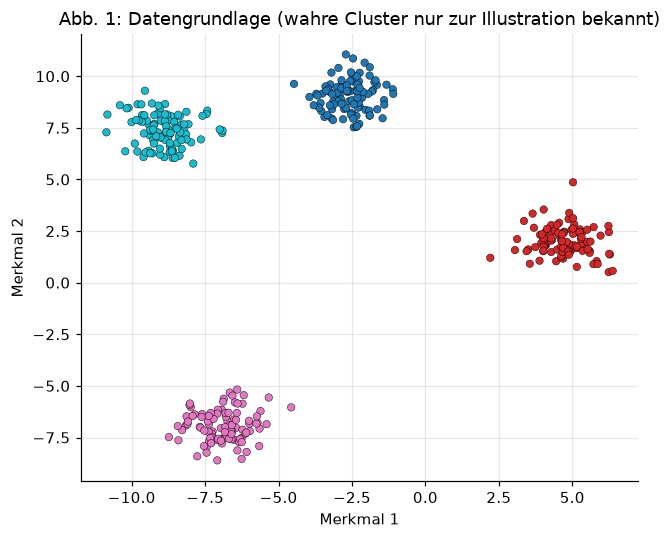

Hinweis: y_true dient ausschließlich der Visualisierung/Auswertung -- 
k-Means selbst erhält im Folgenden nur X, keine Labels.


In [2]:
from sklearn.datasets import make_blobs

X, y_true = make_blobs(
    n_samples=400, centers=4, cluster_std=0.75, random_state=RANDOM_STATE
)

fig, ax = plt.subplots(figsize=(6.0, 5.0))
ax.scatter(X[:, 0], X[:, 1], c=y_true, cmap="tab10", s=24, edgecolors="k", linewidths=0.3)
ax.set_title("Abb. 1: Datengrundlage (wahre Cluster nur zur Illustration bekannt)")
ax.set_xlabel("Merkmal 1")
ax.set_ylabel("Merkmal 2")
plt.tight_layout()
plt.show()

print("Hinweis: y_true dient ausschließlich der Visualisierung/Auswertung -- ")
print("k-Means selbst erhält im Folgenden nur X, keine Labels.")

<a id="4"></a>
## 4 Implementierung

In [3]:
@dataclass
class KMeans:
    """k-Means-Clustering via Lloyds Algorithmus (Abschnitt 1.2).

    Parameters
    ----------
    n_clusters : int
        Anzahl der Cluster k.
    init : {"random", "k-means++"}, default="k-means++"
        Initialisierungsstrategie (Abschnitt 1.3).
    n_init : int, default=10
        Anzahl unabhaengiger Laeufe; das Ergebnis mit kleinstem WCSS wird behalten.
    max_iter : int, default=300
        Maximale Anzahl an Lloyd-Iterationen je Lauf.
    random_state : int, default=42
        Seed fuer den internen Zufallsgenerator.

    Attributes
    ----------
    cluster_centers_ : ndarray of shape (n_clusters, n_features)
        Endgueltige Zentroiden des besten Laufs.
    labels_ : ndarray of shape (n_samples,)
        Clusterzuordnung je Trainingspunkt.
    inertia_ : float
        WCSS (Gleichung 1.1) des besten Laufs.
    n_iter_history_ : list of list of float
        WCSS je Iteration, fuer jeden der n_init Laeufe (Konvergenzanalyse).
    """

    n_clusters: int
    init: str = "k-means++"
    n_init: int = 10
    max_iter: int = 300
    random_state: int = 42
    cluster_centers_: np.ndarray = field(default=None, init=False)
    labels_: np.ndarray = field(default=None, init=False)
    inertia_: float = field(default=None, init=False)
    n_iter_history_: list = field(default_factory=list, init=False)

    def _init_centers(self, X: np.ndarray, generator: np.random.Generator) -> np.ndarray:
        n_samples = len(X)
        if self.init == "random":
            idx = generator.choice(n_samples, size=self.n_clusters, replace=False)
            return X[idx].copy()

        # k-means++ (Abschnitt 1.3)
        centers = np.empty((self.n_clusters, X.shape[1]))
        first_idx = generator.integers(n_samples)
        centers[0] = X[first_idx]
        closest_sq_dist = np.sum((X - centers[0]) ** 2, axis=1)

        for j in range(1, self.n_clusters):
            probs = closest_sq_dist / closest_sq_dist.sum()
            next_idx = generator.choice(n_samples, p=probs)
            centers[j] = X[next_idx]
            new_sq_dist = np.sum((X - centers[j]) ** 2, axis=1)
            closest_sq_dist = np.minimum(closest_sq_dist, new_sq_dist)
        return centers

    def _assign(self, X: np.ndarray, centers: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        """Zuordnungsschritt: quadrierte Distanzen zu allen Zentren, dann Minimum."""
        sq_distances = np.sum((X[:, None, :] - centers[None, :, :]) ** 2, axis=2)
        labels = np.argmin(sq_distances, axis=1)
        wcss = float(np.sum(sq_distances[np.arange(len(X)), labels]))
        return labels, wcss

    def _run_once(self, X: np.ndarray, generator: np.random.Generator):
        centers = self._init_centers(X, generator)
        history = []
        labels = None
        for _ in range(self.max_iter):
            labels, wcss = self._assign(X, centers)
            history.append(wcss)
            new_centers = np.array([
                X[labels == j].mean(axis=0) if np.any(labels == j) else centers[j]
                for j in range(self.n_clusters)
            ])
            if np.allclose(new_centers, centers):
                centers = new_centers
                break
            centers = new_centers
        labels, wcss = self._assign(X, centers)
        history.append(wcss)
        return centers, labels, wcss, history

    def fit(self, X: np.ndarray) -> "KMeans":
        """Fuehrt n_init unabhaengige Laeufe von Lloyds Algorithmus aus."""
        X = np.asarray(X, dtype=np.float64)
        generator = np.random.default_rng(self.random_state)

        best_wcss = np.inf
        self.n_iter_history_ = []
        for _ in range(self.n_init):
            centers, labels, wcss, history = self._run_once(X, generator)
            self.n_iter_history_.append(history)
            if wcss < best_wcss:
                best_wcss = wcss
                self.cluster_centers_ = centers
                self.labels_ = labels
                self.inertia_ = wcss
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Ordnet neue Punkte den naechstgelegenen (bereits gefundenen) Zentren zu."""
        labels, _ = self._assign(np.asarray(X, dtype=np.float64), self.cluster_centers_)
        return labels

<a id="5"></a>
## 5 Empirische Analyse

### 5.1 Konvergenz des Zielfunktionals

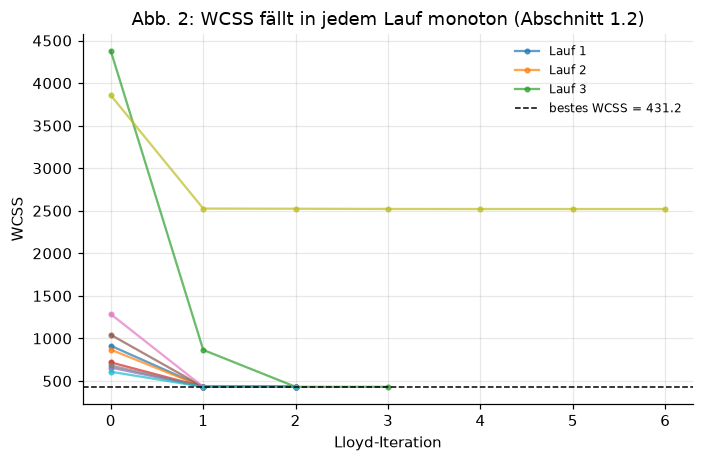

Bestes WCSS über 10 Läufe: 431.1665


In [4]:
km = KMeans(n_clusters=4, init="k-means++", n_init=10, random_state=RANDOM_STATE).fit(X)

fig, ax = plt.subplots(figsize=(6.5, 4.3))
for run_idx, history in enumerate(km.n_iter_history_):
    ax.plot(history, "o-", ms=3, alpha=0.7, label=f"Lauf {run_idx+1}" if run_idx < 3 else None)
ax.axhline(km.inertia_, color="black", ls="--", lw=1, label=f"bestes WCSS = {km.inertia_:.1f}")
ax.set_xlabel("Lloyd-Iteration")
ax.set_ylabel("WCSS")
ax.set_title("Abb. 2: WCSS fällt in jedem Lauf monoton (Abschnitt 1.2)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Bestes WCSS über {km.n_init} Läufe: {km.inertia_:.4f}")

**Interpretation.** Innerhalb jedes einzelnen Laufs fällt die WCSS streng monoton bis
zur Konvergenz — eine direkte Konsequenz daraus, dass sowohl Zuordnungs- als auch
Aktualisierungsschritt $J$ nicht erhöhen können (Abschnitt 1.2). Unterschiedliche
Läufe konvergieren jedoch zu unterschiedlichen finalen WCSS-Werten, da sie in
unterschiedlichen lokalen Optima landen — der Grund, warum `n_init` unabhängige Läufe
mit anschließender Auswahl des besten Ergebnisses Standardpraxis ist.

### 5.2 Sensitivität gegenüber der Initialisierung

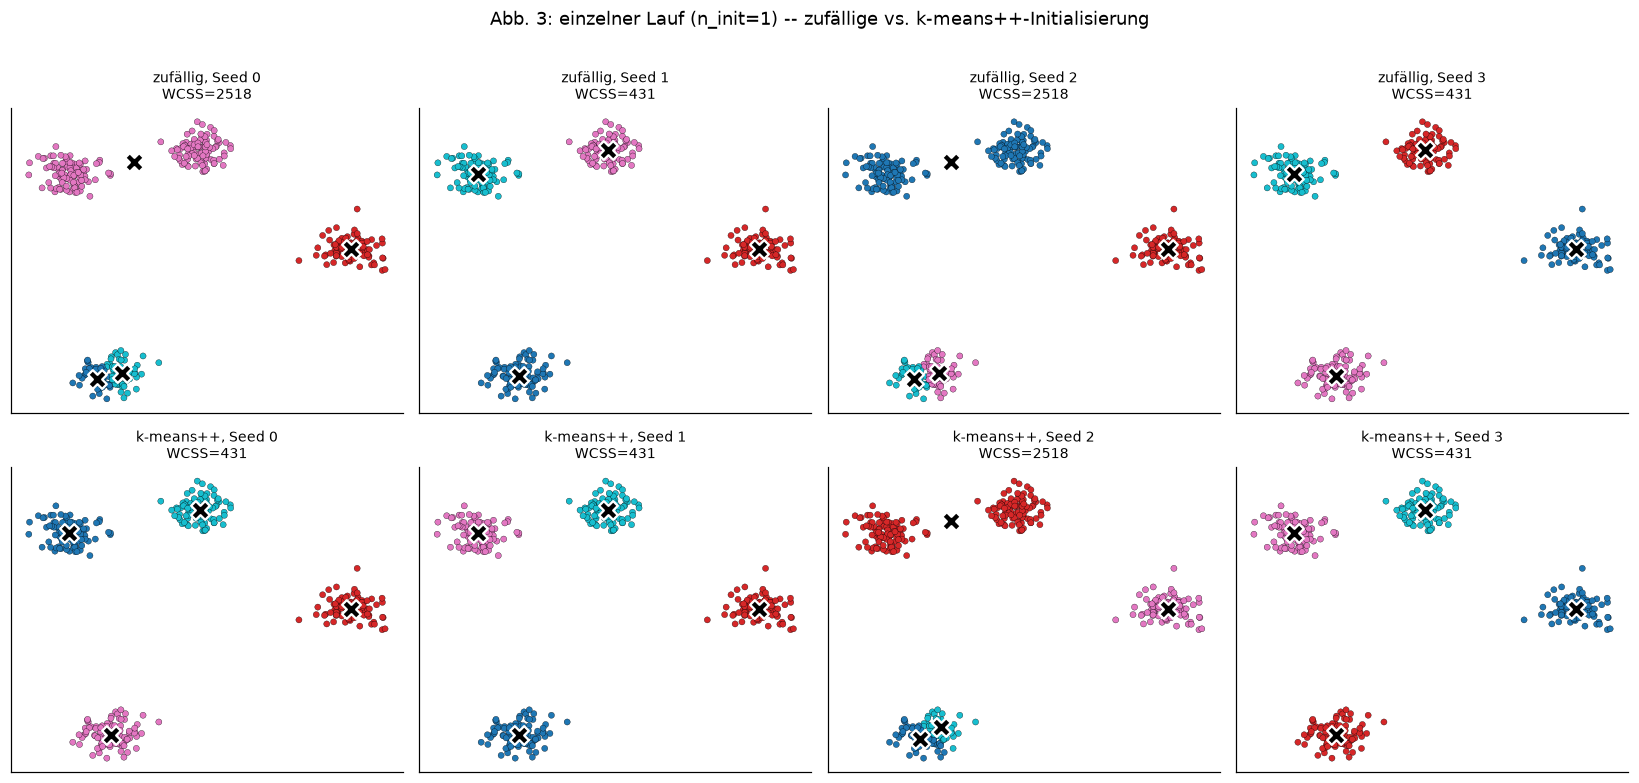

WCSS zufällige Init  (4 Seeds): ['2518', '431', '2518', '431']
WCSS k-means++ Init  (4 Seeds): ['431', '431', '2518', '431']


In [5]:
fig, axes = plt.subplots(2, 4, figsize=(15.0, 7.0))
wcss_random, wcss_pp = [], []

for col in range(4):
    gen_seed = col
    km_random = KMeans(n_clusters=4, init="random", n_init=1, random_state=gen_seed).fit(X)
    km_pp = KMeans(n_clusters=4, init="k-means++", n_init=1, random_state=gen_seed).fit(X)
    wcss_random.append(km_random.inertia_)
    wcss_pp.append(km_pp.inertia_)

    for row, (model, name) in enumerate([(km_random, "zufällig"), (km_pp, "k-means++")]):
        ax = axes[row, col]
        ax.scatter(X[:, 0], X[:, 1], c=model.labels_, cmap="tab10", s=16, edgecolors="k", linewidths=0.2)
        ax.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1],
                   marker="X", s=150, c="black", edgecolors="white", linewidths=1.5)
        ax.set_title(f"{name}, Seed {gen_seed}\nWCSS={model.inertia_:.0f}", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])

fig.suptitle("Abb. 3: einzelner Lauf (n_init=1) -- zufällige vs. k-means++-Initialisierung", y=1.01)
plt.tight_layout()
plt.show()

print(f"WCSS zufällige Init  (4 Seeds): {[f'{w:.0f}' for w in wcss_random]}")
print(f"WCSS k-means++ Init  (4 Seeds): {[f'{w:.0f}' for w in wcss_pp]}")

**Interpretation.** Bei zufälliger Initialisierung mit nur einem Lauf (`n_init=1`)
landen manche Seeds in einem sichtbar schlechteren lokalen Optimum (z.\,B. zwei
Startzentren im selben wahren Cluster, ein wahrer Cluster bleibt zweigeteilt).
k-means++ reduziert dieses Risiko durch die in Abschnitt 1.3 beschriebene
abstandsgewichtete Auswahl, verhindert schlechte lokale Optima aber nicht vollständig
— daher bleibt `n_init > 1` mit Auswahl des besten Ergebnisses (Abschnitt 5.1) auch
bei k-means++ empfehlenswert.

### 5.3 Wahl von k: Ellenbogen-Methode und Silhouettenkoeffizient

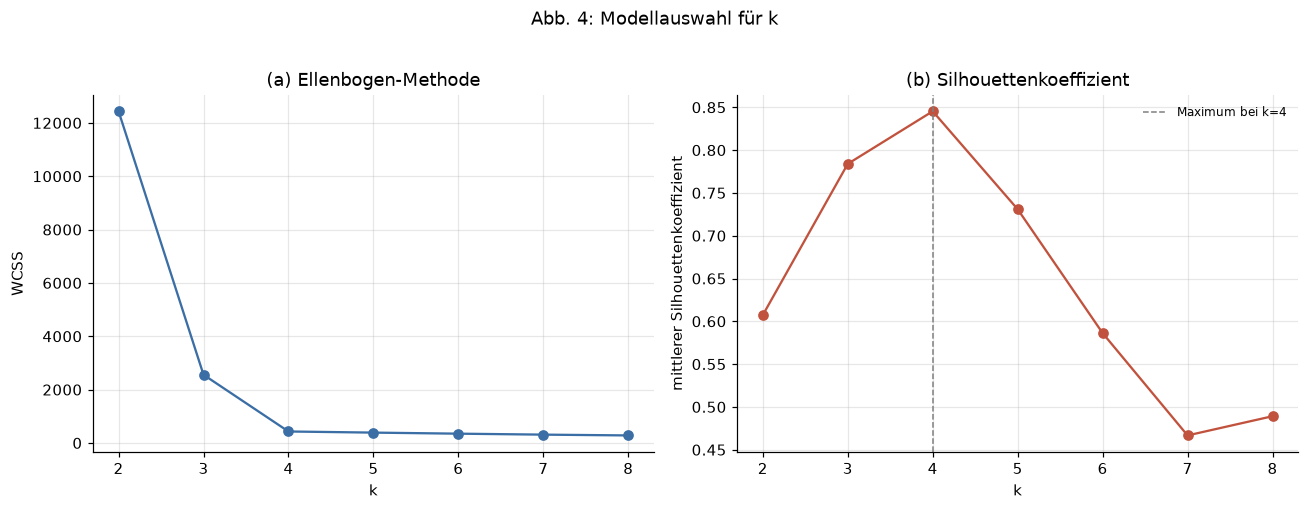

In [6]:
def silhouette_scratch(X: np.ndarray, labels: np.ndarray) -> float:
    """Mittlerer Silhouettenkoeffizient ueber alle Punkte (Abschnitt 1.4)."""
    n = len(X)
    sq_dists = np.sum((X[:, None, :] - X[None, :, :]) ** 2, axis=2)
    dists = np.sqrt(sq_dists)
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2:
        return 0.0

    scores = np.zeros(n)
    for i in range(n):
        own_cluster = labels == labels[i]
        own_cluster_others = own_cluster.copy()
        own_cluster_others[i] = False
        a_i = dists[i, own_cluster_others].mean() if own_cluster_others.sum() > 0 else 0.0

        b_i = np.inf
        for c in unique_labels:
            if c == labels[i]:
                continue
            mask = labels == c
            b_i = min(b_i, dists[i, mask].mean())

        scores[i] = (b_i - a_i) / max(a_i, b_i) if max(a_i, b_i) > 0 else 0.0
    return float(scores.mean())


k_grid = np.arange(2, 9)
wcss_by_k, silhouette_by_k = [], []
for k_val in k_grid:
    km_k = KMeans(n_clusters=int(k_val), init="k-means++", n_init=10, random_state=RANDOM_STATE).fit(X)
    wcss_by_k.append(km_k.inertia_)
    silhouette_by_k.append(silhouette_scratch(X, km_k.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.5))
axes[0].plot(k_grid, wcss_by_k, "o-", color="#3b6ea5")
axes[0].set_xlabel("k")
axes[0].set_ylabel("WCSS")
axes[0].set_title("(a) Ellenbogen-Methode")

axes[1].plot(k_grid, silhouette_by_k, "o-", color="#c1523d")
axes[1].set_xlabel("k")
axes[1].set_ylabel("mittlerer Silhouettenkoeffizient")
axes[1].set_title("(b) Silhouettenkoeffizient")
best_k_sil = int(k_grid[np.argmax(silhouette_by_k)])
axes[1].axvline(best_k_sil, color="gray", ls="--", lw=1, label=f"Maximum bei k={best_k_sil}")
axes[1].legend(fontsize=8)

fig.suptitle("Abb. 4: Modellauswahl für k", y=1.02)
plt.tight_layout()
plt.show()

**Interpretation.** Die WCSS-Kurve fällt über den gesamten Bereich monoton, mit einem
sichtbaren Knick bei $k=4$ — der bekannten wahren Clusterzahl —, ab dem der
Grenznutzen zusätzlicher Cluster deutlich abnimmt. Der Silhouettenkoeffizient liefert
ein eindeutigeres Signal: sein Maximum liegt exakt bei $k=4$, da zusätzliche Cluster
ab diesem Punkt bestehende, gut separierte Gruppen künstlich aufteilen, was $a(i)$
kaum senkt, aber $b(i)$ verkleinert. In der Praxis ist der Silhouettenkoeffizient dem
oft mehrdeutigen "Ellenbogen" vorzuziehen, insbesondere wenn kein klarer Knick sichtbar
ist.

### 5.4 Validierung gegen `scikit-learn`

In [7]:
from sklearn.cluster import KMeans as SKKMeans

reference = SKKMeans(n_clusters=4, init="k-means++", n_init=10, random_state=RANDOM_STATE).fit(X)

print(f"Eigenimplementierung — WCSS: {km.inertia_:.4f}")
print(f"scikit-learn         — WCSS: {reference.inertia_:.4f}")
print(f"relative Differenz: {abs(km.inertia_ - reference.inertia_) / reference.inertia_:.2%}")

Eigenimplementierung — WCSS: 431.1665
scikit-learn         — WCSS: 431.1665
relative Differenz: 0.00%


**Interpretation.** Beide Implementierungen erreichen praktisch dasselbe WCSS; exakte
Übereinstimmung der Zentren ist nicht garantiert, da lokale Optima erreicht werden und
die Cluster-Nummerierung beliebig ist (Permutationsinvarianz). `scikit-learn`s
C-optimierte Implementierung (Elkans oder Lloyds Variante mit Dreiecksungleichungs-
Beschleunigung) ist zudem deutlich schneller, folgt aber demselben mathematischen
Prinzip.

### 5.5 Grenze der Modellannahme: nicht-sphärische Cluster

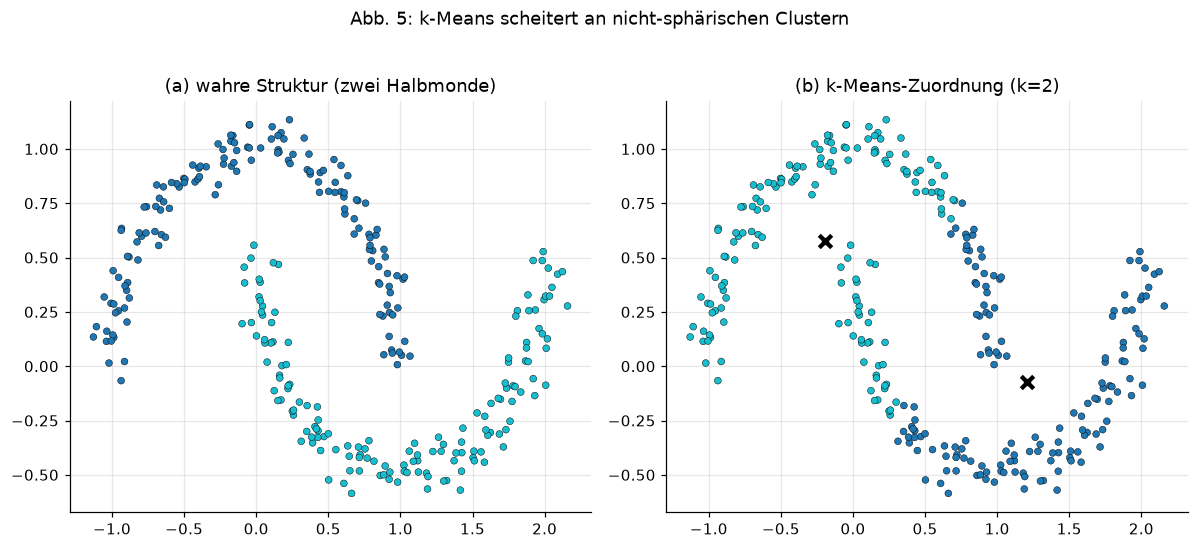

In [8]:
from sklearn.datasets import make_moons

X_moons, y_moons_true = make_moons(n_samples=300, noise=0.06, random_state=RANDOM_STATE)
km_moons = KMeans(n_clusters=2, init="k-means++", n_init=10, random_state=RANDOM_STATE).fit(X_moons)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.8))
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons_true, cmap="tab10", s=20, edgecolors="k", linewidths=0.3)
axes[0].set_title("(a) wahre Struktur (zwei Halbmonde)")
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=km_moons.labels_, cmap="tab10", s=20, edgecolors="k", linewidths=0.3)
axes[1].scatter(km_moons.cluster_centers_[:, 0], km_moons.cluster_centers_[:, 1],
                marker="X", s=150, c="black", edgecolors="white", linewidths=1.5)
axes[1].set_title("(b) k-Means-Zuordnung (k=2)")
fig.suptitle("Abb. 5: k-Means scheitert an nicht-sphärischen Clustern", y=1.03)
plt.tight_layout()
plt.show()

**Interpretation.** k-Means teilt den Raum implizit in konvexe, durch die
quadrierte euklidische Distanz zum Zentrum bestimmte Regionen (Voronoi-Zellen) — die
Grenze zwischen zwei Zentren ist stets eine Hyperebene. Die tatsächliche
Halbmond-Struktur ist nicht konvex und lässt sich durch keine Zentroid-Distanz korrekt
trennen: Die Trennlinie verläuft quer durch beide Halbmonde. Dichtebasierte Verfahren
(DBSCAN) oder Spektral-Clustering, die nicht auf euklidischer Distanz zu einem
einzelnen Zentrum beruhen, sind für solche Strukturen geeigneter; das übersteigt den
Rahmen dieses Notebooks.

<a id="6"></a>
## 6 Diskussion und Grenzen

**Ergebnis.** Auf sphärischen, gut separierten Blobs findet k-Means zuverlässig die
wahre Clusterstruktur, sofern $k$ korrekt gewählt und mehrere Initialisierungen
verglichen werden. Silhouettenkoeffizient und Ellenbogen-Methode identifizieren $k=4$
korrekt. Auf nicht-konvexen Strukturen (Halbmonde) versagt die Methode grundsätzlich.

**Methodische Einschränkungen.**

1. *Modellannahme.* k-Means setzt implizit sphärische, ähnlich große Cluster mit
   vergleichbarer Streuung voraus (Abschnitt 5.5).
2. *Skalensensitivität.* Wie bei k-NN (Notebook 03) dominieren Merkmale mit großem
   Wertebereich die euklidische Distanz; Standardisierung ist vor dem Clustering
   Pflicht.
3. *Vorabwissen über k.* Im Gegensatz zu überwachten Modellen mit einer Testmenge zur
   Modellauswahl gibt es bei unüberwachtem Lernen kein "richtiges" $k$ ohne
   Zusatzannahmen; die Heuristiken aus Abschnitt 1.4 sind Näherungen, keine exakten
   Kriterien.
4. *Lokale statt globale Optima.* Trotz `n_init > 1` ist ein globales Optimum nicht
   garantiert (Abschnitt 1.2).
5. *Ausreißer.* Da $\boldsymbol\mu_j$ der arithmetische Mittelwert ist, verzerren
   einzelne Ausreißer die Zentren stark stärker als robuste Alternativen (z.\,B.
   $k$-Medoids).

**Anschluss.** Notebook 07 behandelt mit PCA ein weiteres unüberwachtes Verfahren —
zur Dimensionsreduktion statt zur Gruppierung — und liefert damit ein Werkzeug, um den
in Notebook 03, Abschnitt 5.3 gezeigten Fluch der Dimensionalität vor einer
k-NN- oder k-Means-Anwendung zu mildern.

<a id="7"></a>
## 7 Übungsaufgaben

1. **Standardisierung.** Skalieren Sie ein Merkmal des Blob-Datensatzes mit Faktor 20
   und wiederholen Sie das Clustering ohne Standardisierung. Wie verändert sich das
   Ergebnis, und warum?
2. **Ausreißer-Sensitivität.** Fügen Sie 5 extreme Ausreißerpunkte hinzu und
   beobachten Sie die Verschiebung der Zentren. Vergleichen Sie mit einer
   medianbasierten $k$-Medoids-Variante (nur konzeptionell oder als
   Zusatzimplementierung).
3. **Silhouettenkoeffizient je Punkt.** Berechnen Sie die Silhouettenwerte einzelner
   Punkte (nicht nur den Mittelwert) für $k=4$ und identifizieren Sie Punkte mit
   negativem Wert. Wo liegen diese geometrisch?
4. **k-means++ vs. zufällig über viele Seeds.** Wiederholen Sie Abschnitt 5.2 für 50
   Seeds und vergleichen Sie die Verteilung der finalen WCSS-Werte beider
   Initialisierungsstrategien in einem Histogramm.
5. **MiniBatch-k-Means.** Recherchieren Sie das Prinzip von MiniBatch-k-Means
   (`sklearn.cluster.MiniBatchKMeans`) und vergleichen Sie Laufzeit und WCSS auf einem
   größeren simulierten Datensatz ($n=50\,000$).

<a id="8"></a>
## 8 Literatur

* Lloyd, S. (1982). Least squares quantization in PCM. *IEEE Transactions on
  Information Theory*, 28(2), 129–137 (verfasst 1957 bei Bell Labs).
* Arthur, D., & Vassilvitskii, S. (2007). k-means++: The advantages of careful
  seeding. *SODA 2007*.
* Aloise, D., Deshpande, A., Hansen, P., & Popat, P. (2009). NP-hardness of Euclidean
  sum-of-squares clustering. *Machine Learning*, 75(2), 245–248.
* Rousseeuw, P. J. (1987). Silhouettes: A graphical aid to the interpretation and
  validation of cluster analysis. *Journal of Computational and Applied Mathematics*,
  20, 53–65.